# โครงงาน Image Classification: การจำแนกตัวอักษรไทย
**เป้าหมาย:** พัฒนาแบบจำลอง Machine Learning (CNN) สำหรับจำแนกประเภทภาพตัวอักษรไทยและสัญลักษณ์ต่างๆ รวม 95 คลาส

**ชุดข้อมูล:** PimAksornThai (ดาวน์โหลดจาก Kaggle) ประกอบด้วยภาพตัวอักษรที่สร้างจากฟอนต์ 406 แบบ จำนวนกว่า 38,570 ภาพ

**สิทธิ์การใช้งาน:** Attribution 4.0 International (CC BY 4.0)


In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random

In [3]:
DATASET_PATH = '../datasets' 

class_paths = []
image_counts = {}

for root, dirs, files in os.walk(DATASET_PATH):
    images = [f for f in files if f.endswith(('.png', '.jpg', '.jpeg'))]
    if images:
        class_name = os.path.basename(root)
        class_paths.append(root)
        image_counts[class_name] = len(images)

print(f"ค้นพบข้อมูลทั้งหมด: {len(image_counts)} คลาส")
print(f"จำนวนรูปภาพรวม: {sum(image_counts.values())} ภาพ")

ค้นพบข้อมูลทั้งหมด: 95 คลาส
จำนวนรูปภาพรวม: 38570 ภาพ


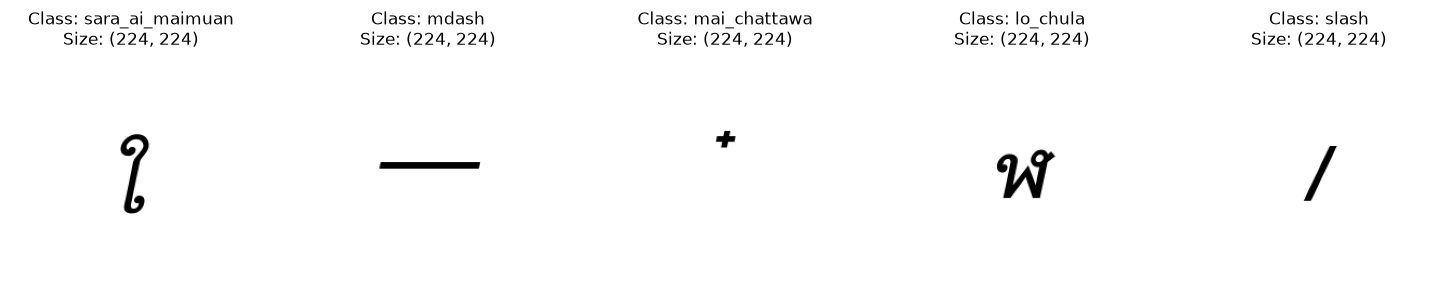

In [4]:
sample_classes = random.sample(class_paths, 5)

plt.figure(figsize=(15, 3))
for i, path in enumerate(sample_classes):
    class_name = os.path.basename(path)
    img_name = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))][0]
    img_path = os.path.join(path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {class_name}\nSize: {img.size}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64
X = [] 
y = [] 

print("กำลังโหลดและประมวลผลรูปภาพ กรุณารอสักครู่...")

for path in class_paths:
    class_name = os.path.basename(path)
    images = [f for f in os.listdir(path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    for file in images:
        img_path = os.path.join(path, file)
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            
            img_array = np.array(img) / 255.0
            
            X.append(img_array)
            y.append(class_name)
        except Exception as e:
            print(f"ข้ามไฟล์ที่อ่านไม่ได้: {img_path}")

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
NUM_CLASSES = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("การเตรียมข้อมูลเสร็จสมบูรณ์!")
print(f"ข้อมูลชุด Train: {X_train.shape}")
print(f"ข้อมูลชุด Test: {X_test.shape}")

กำลังโหลดและประมวลผลรูปภาพ กรุณารอสักครู่...
การเตรียมข้อมูลเสร็จสมบูรณ์!
ข้อมูลชุด Train: (30856, 64, 64, 1)
ข้อมูลชุด Test: (7714, 64, 64, 1)
